In [9]:
import esigmapy
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

In [2]:
mean_anomaly_array = np.linspace(-np.pi, np.pi, 50)

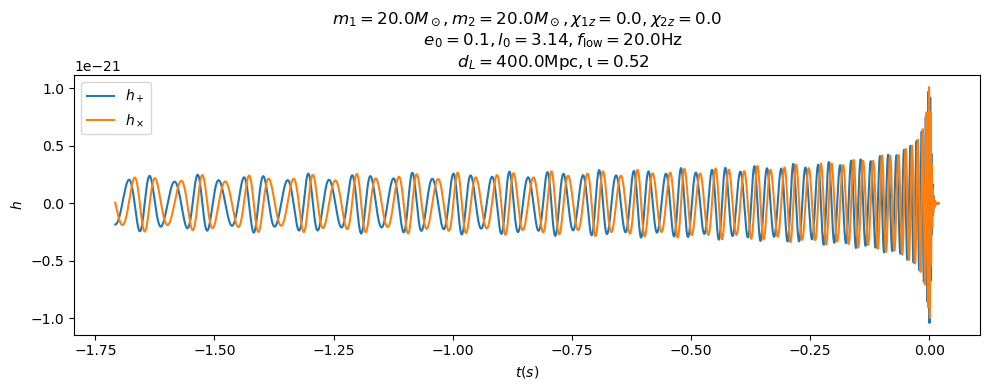

In [35]:
m1 = 20.
m2 = 20.
spin1z = 0.0
spin2z = 0.0
eccentricity = 0.1
mean_anomaly = np.pi
modes_to_use = [(2,2)]

distance = 400. 
inclination = 30 * np.pi/180.

f_low = 20. 
delta_t = 1/2**14

ref_hp, ref_hc = esigmapy.get_imr_esigma_waveform(mass1=m1, 
                                        mass2=m2,
                                        spin1z=spin1z, 
                                        spin2z=spin2z,
                                        eccentricity=eccentricity,
                                        mean_anomaly=mean_anomaly,
                                        distance=distance,
                                        inclination=inclination,
                                        f_lower=f_low,
                                        delta_t=delta_t,
                                        modes_to_use=modes_to_use)

plt.figure(figsize=(10,4))
plt.title(fr"""$m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$""")
ref_hp.plot(label=r"$h_+$")
ref_hc.plot(label=r"$h_\times$")
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()

In [54]:
ref_signal = ref_hp - 1j * ref_hc
ref_time = list(ref_hp.sample_times)

X_amp = np.zeros(shape=(50, len(abs(ref_signal))))
X_phase = np.zeros(shape=(50, len(np.unwrap(np.angle((ref_signal))))))

In [55]:
for i, mean_anomaly in enumerate(mean_anomaly_array):
    hp, hc = esigmapy.get_imr_esigma_waveform(
        mass1=m1, mass2=m2,
        spin1z=spin1z, spin2z=spin2z,
        eccentricity=eccentricity, mean_anomaly=mean_anomaly,
        distance=distance, inclination=inclination,
        f_lower=f_low, delta_t=delta_t,
        modes_to_use=modes_to_use
    )
    
    signal = hp - 1j * hc
    test_time = list(signal.sample_times)
    
    amp_spline = CubicSpline(test_time, np.abs(signal))
    test_sample_amp = amp_spline(ref_time)
    
    phase_spline = CubicSpline(test_time, np.unwrap(np.angle(signal)))
    test_sample_phase = phase_spline(ref_time)
    
    test_sample_phase -= test_sample_phase[0]
    
    X_amp[i, :] = test_sample_amp
    X_phase[i, :] = test_sample_phase

In [56]:
U_amp, s_amp, Vt_amp = np.linalg.svd(X_amp, full_matrices=False)
U_phase, s_phase, Vt_phase = np.linalg.svd(X_phase, full_matrices=False)

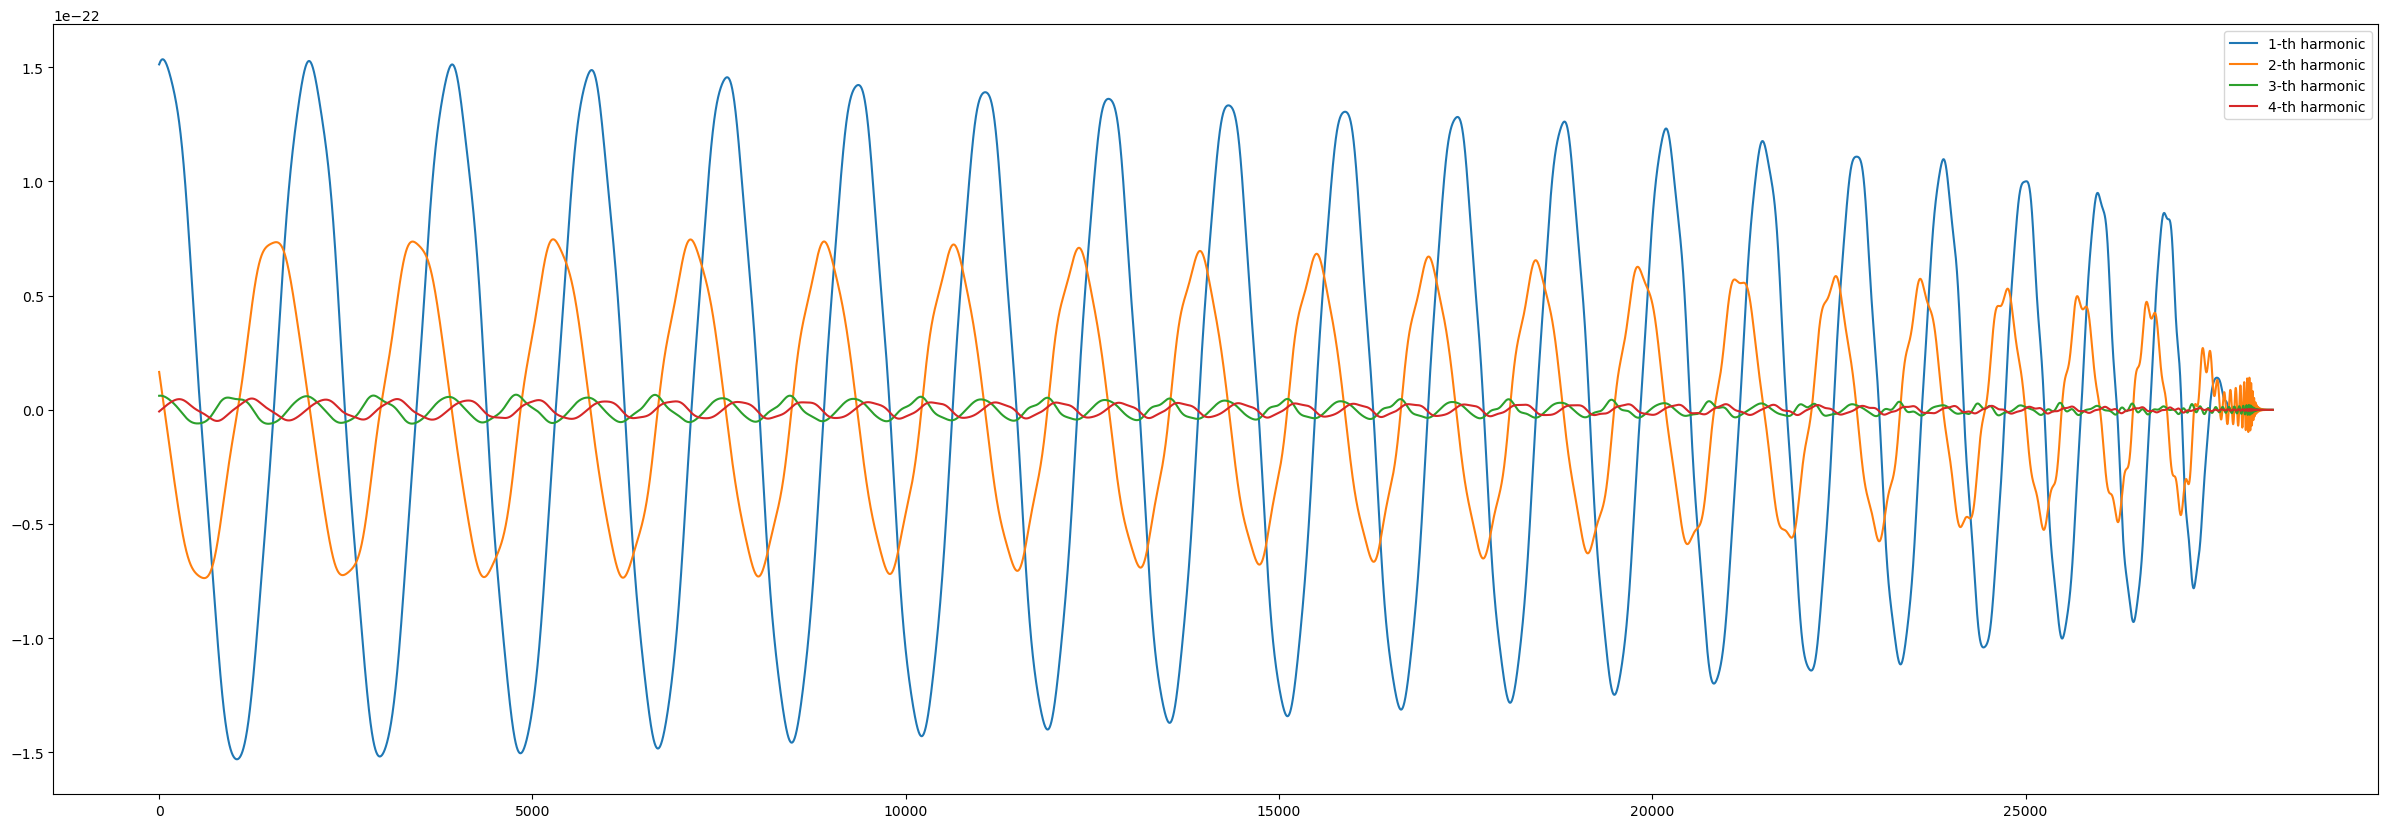

In [66]:
plt.figure(figsize=(30, 10))

for i in range(1,5):
        plt.plot(1/i * s_amp[i] * Vt_amp[i], label=f'{i}-th harmonic')

plt.legend()
plt.show()

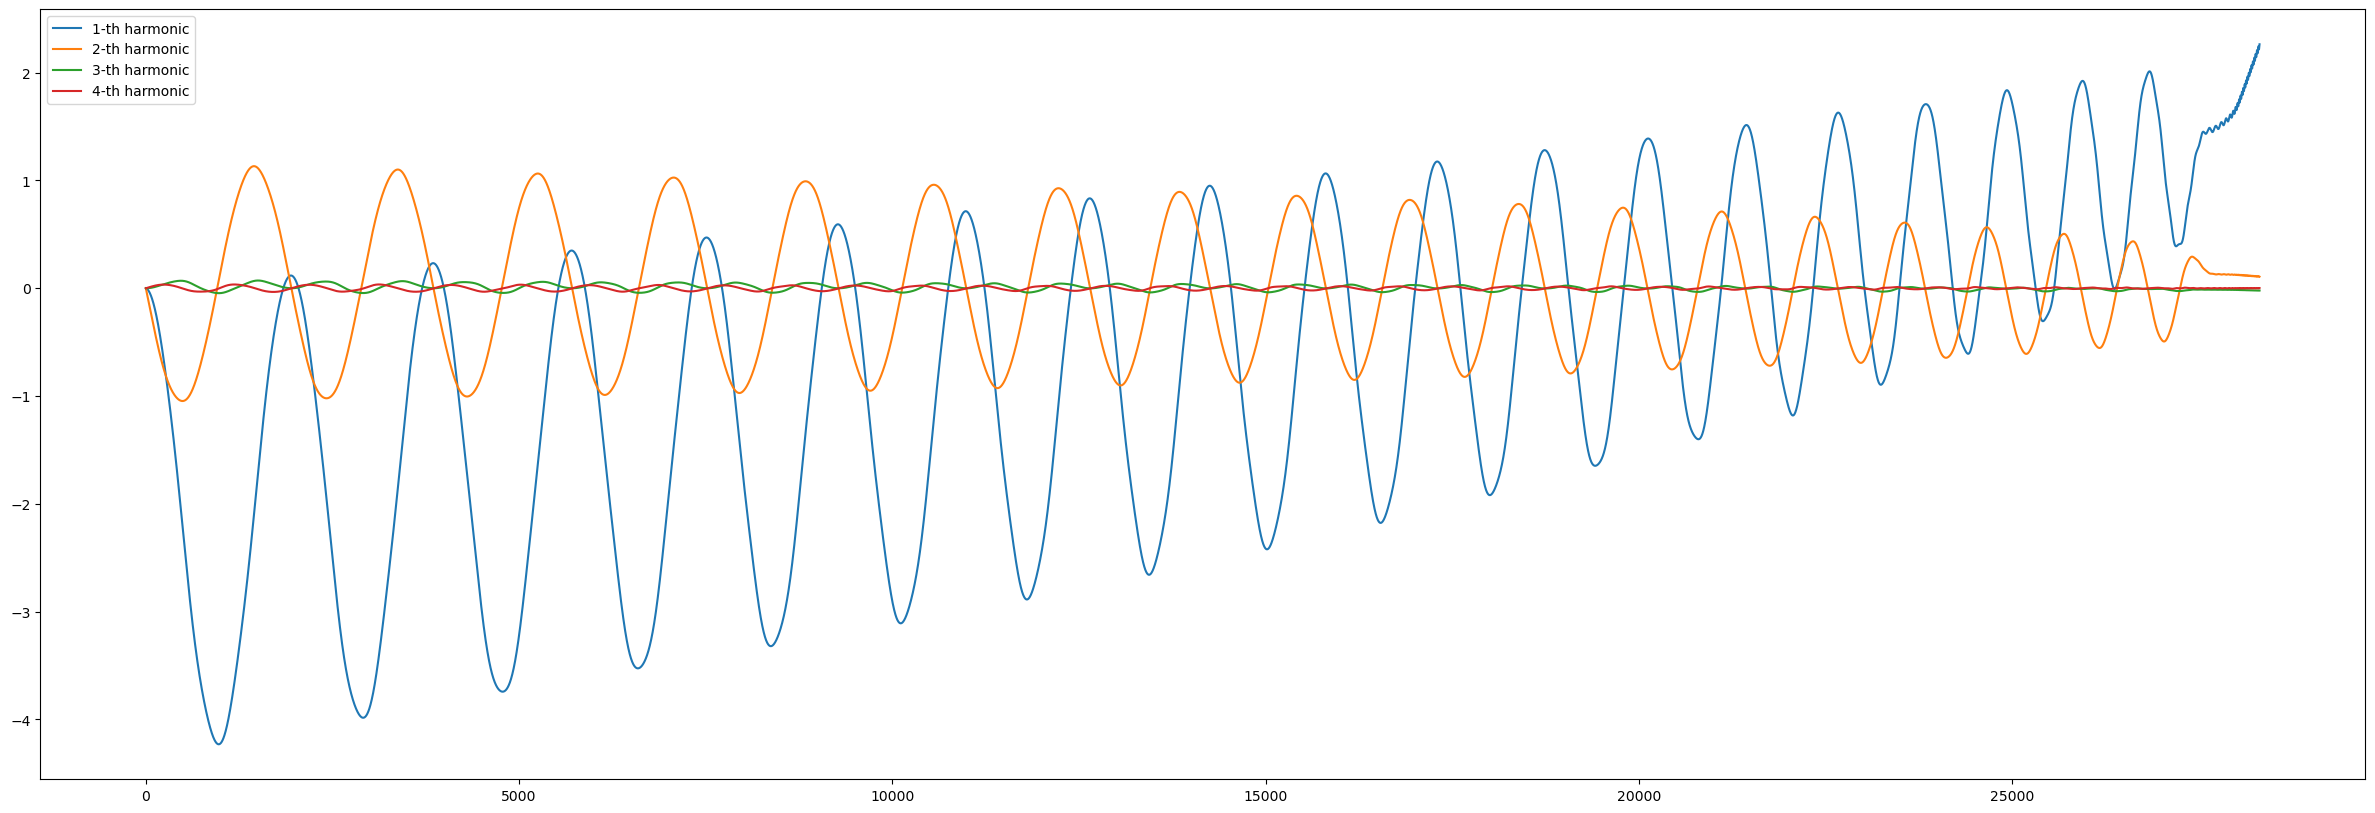

In [64]:
plt.figure(figsize=(30, 10))

for i in range(1,5):
    plt.plot(1/i * s_phase[i] * Vt_phase[i], label=f'{i}-th harmonic')

plt.legend()
plt.show()